In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("bacteria_list_200.csv")

print(df.head())

print(df.info())

print(df.isnull().sum())

                        Name              Family  \
0           Escherichia coli  Enterobacteriaceae   
1      Staphylococcus aureus   Staphylococcaceae   
2  Lactobacillus acidophilus    Lactobacillaceae   
3          Bacillus subtilis         Bacillaceae   
4      Clostridium botulinum      Clostridiaceae   

                     Where Found Harmful to Humans  
0               Intestinal tract               Yes  
1           Skin, nasal passages               Yes  
2        Human mouth & intestine                No  
3                           Soil                No  
4  Soil, improperly canned foods               Yes  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Name               199 non-null    object
 1   Family             199 non-null    object
 2   Where Found        199 non-null    object
 3   Harmful to Humans  199 no

In [3]:
df = df.drop_duplicates()

df.columns = df.columns.str.strip()

df['Harmful to Humans'] = df['Harmful to Humans'].str.strip()

print(df.shape)

(196, 4)


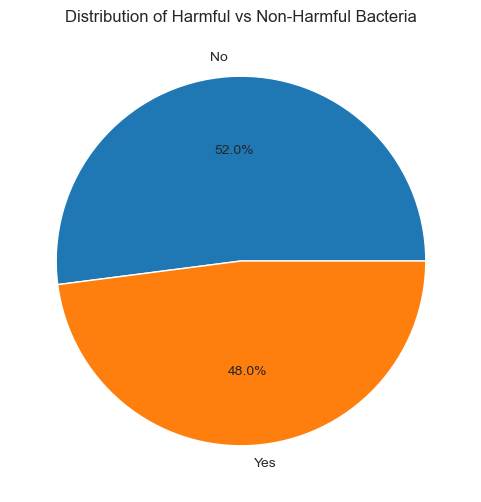

In [4]:
harmful_count = df['Harmful to Humans'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    harmful_count,
    labels=harmful_count.index,
    autopct='%1.1f%%'
)
plt.title("Distribution of Harmful vs Non-Harmful Bacteria")
plt.show()

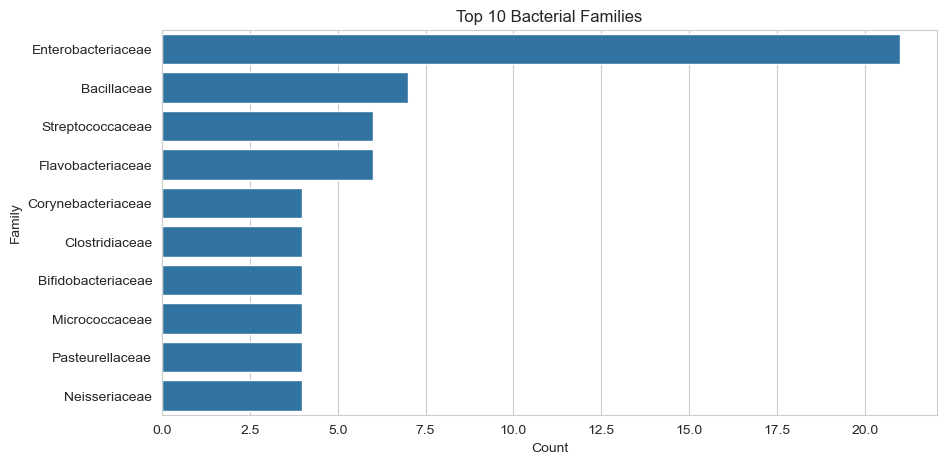

In [5]:
top_family = df['Family'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_family.values,
    y=top_family.index
)

plt.title("Top 10 Bacterial Families")
plt.xlabel("Count")
plt.ylabel("Family")
plt.show()

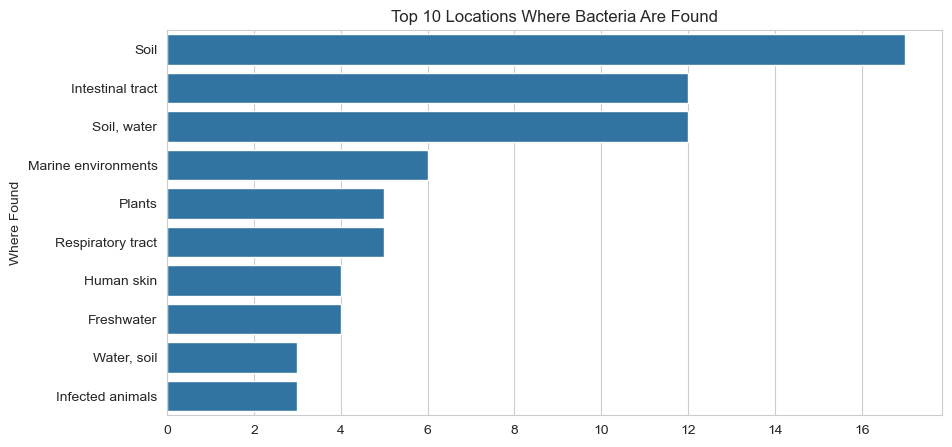

In [6]:
top_location = df['Where Found'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_location.values,
    y=top_location.index
)

plt.title("Top 10 Locations Where Bacteria Are Found")
plt.show()

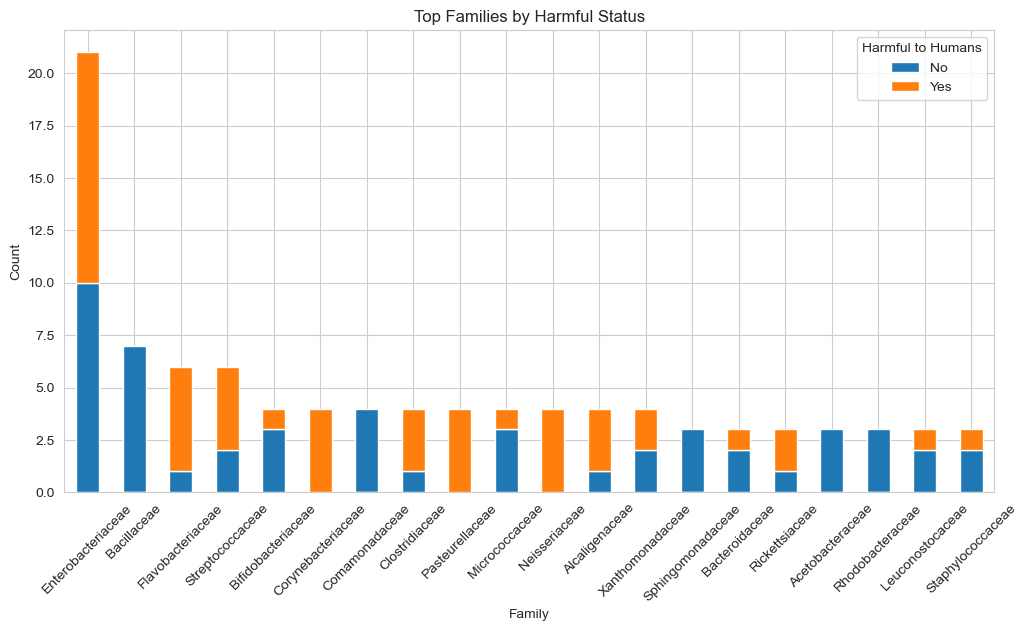

In [7]:
family_harmful = pd.crosstab(
    df['Family'],
    df['Harmful to Humans']
)

top20 = family_harmful.sum(axis=1)\
                      .sort_values(ascending=False)\
                      .head(20)

family_harmful = family_harmful.loc[top20.index]

family_harmful.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Top Families by Harmful Status")
plt.xlabel("Family")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

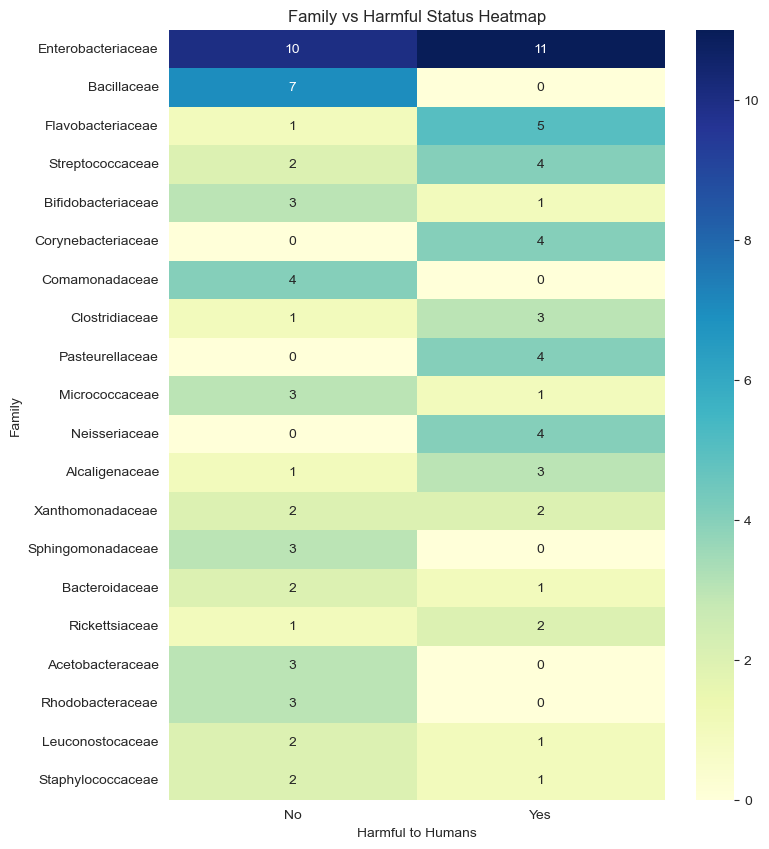

In [8]:
heatmap_data = pd.crosstab(
    df['Family'],
    df['Harmful to Humans']
)

top20 = heatmap_data.sum(axis=1)\
                    .sort_values(ascending=False)\
                    .head(20)

heatmap_data = heatmap_data.loc[top20.index]

plt.figure(figsize=(8,10))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='YlGnBu'
)

plt.title("Family vs Harmful Status Heatmap")
plt.show()